In [3]:
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import ttest_ind

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap, MPRAHead, AlphaGenomeMPRA

# Local layout: weights at pytorch_base_model/, ckpts at models/{name}/best_stage2.pt
eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CKPT_DIR = os.path.join(REPO, 'models')

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- libraries: sequences + precomputed attributions ---
df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

# --- eigen cache + focused library ---
with open(os.path.join(REPO, 'genomic_targets', 'data', 'eigen_analysis.pkl'), 'rb') as f:
    cached = pickle.load(f)
ei1_var = cached['ei1_var']; corrs = cached['corrs']; eixr = ei1_var * corrs

with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
focus_idx = target_lib['df']['seq_idx'].values

# --- per-replicate MPRA stats ---
MPRA_DIR = os.path.join(REPO, 'data', 'full_joint_mpra')
COLS = ['cell', 'rep', 'name', 'dna', 'rna', 'ratio', 'log2_ratio', 'n_bc']
def _load(cell):
    return pd.concat([pd.read_csv(f, sep='\t', header=None, names=COLS)
                      for f in sorted(glob.glob(f'{MPRA_DIR}/{cell}/{cell}_rep*.tsv'))],
                     ignore_index=True)
hep_w = _load('HepG2').pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = _load('K562' ).pivot_table(index='name', columns='rep', values='log2_ratio')
shared = hep_w.index.intersection(k_w.index)
H, K = hep_w.loc[shared].values, k_w.loc[shared].values
ok = np.isfinite(H).all(1) & np.isfinite(K).all(1)
_, pv = ttest_ind(H[ok], K[ok], axis=1, equal_var=False)
diffs = df['name'].map(dict(zip(shared[ok], H[ok].mean(1) - K[ok].mean(1)))).values.astype(float)
pvals = df['name'].map(dict(zip(shared[ok], pv))).values.astype(float)

# --- heavy load: models on GPU (ckpts live at models/{name}/best_stage2.pt) ---
def _load_model_patched(self, ct, squeeze=False):
    eigen_steering._load_heavy_deps()
    name = self.model_names[ct]
    ckpt_path = os.path.join(CKPT_DIR, name, 'best_stage2.pt')
    print(f"  Loading {ct}: {ckpt_path}")
    enc = eigen_steering.AlphaGenome.from_pretrained(eigen_steering.WEIGHTS_PATH, device='cpu')
    eigen_steering.remove_all_heads(enc)
    hd = MPRAHead()
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    return AlphaGenomeMPRA(enc, hd, squeeze=squeeze).to(self.device).eval()

EigenMap._load_model = _load_model_patched
models = em._load_models()

print(f'\n{len(df)} seqs on {DEVICE} | EIxr n={len(eixr)} | focus={len(focus_idx)} | mpra={np.isfinite(diffs).sum()}')
for ct, m in models.items():
    print(f'  {ct}: {sum(p.numel() for p in m.parameters())/1e6:.2f}M params on {next(m.parameters()).device}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt

56975 seqs on cuda | EIxr n=56975 | focus=1059 | mpra=56962
  K562: 408.64M params on cuda:0
  HepG2: 408.64M params on cuda:0


condition
same-diff    353
diff-diff    353
same-same    353
Name: count, dtype: int64
{'same-same': 53997, 'diff-diff': 26012, 'same-diff': 56772}


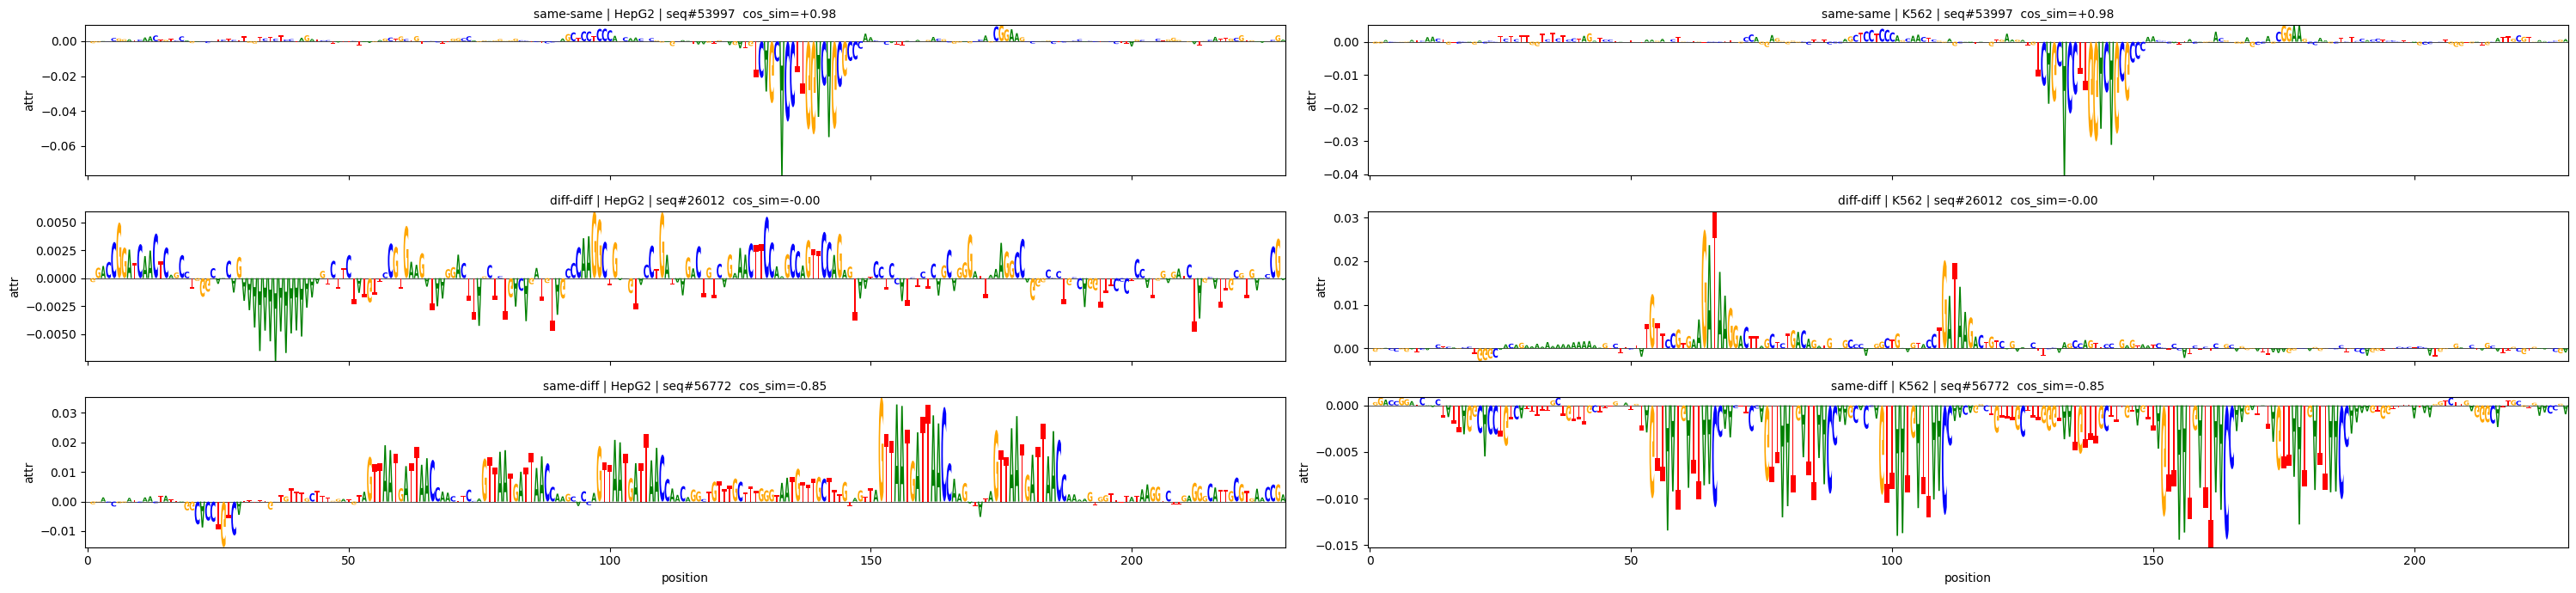

In [4]:
import logomaker as lm

lib = target_lib['df']
print(lib['condition'].value_counts())

reps = {cond: int(lib[lib['condition'] == cond].iloc[0]['seq_idx'])
        for cond in ['same-same', 'diff-diff', 'same-diff']}
print(reps)

# enhancer-only (1x230) cosine sim over per-position importance (== EI corrs)
cs_all = em.cosine_similarity(enhancer_only=True, mode='importance', zscore=True)  # (N,)

ENH_LEN = eigen_steering.ENHANCER_LEN  # 230

fig, axes = plt.subplots(3, 2, figsize=(30, 7), sharex=True)
for r, (name, i) in enumerate(reps.items()):
    for c, ct in enumerate(['HepG2', 'K562']):
        att = em.attr[ct][i, :, :ENH_LEN].T  # (230, 4) enhancer only
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=axes[r, c])
        axes[r, c].set_title(f'{name} | {ct} | seq#{i}  cos_sim={cs_all[i]:+.2f}', fontsize=10)
        axes[r, c].set_ylabel('attr')
axes[-1, 0].set_xlabel('position'); axes[-1, 1].set_xlabel('position')
plt.tight_layout(); plt.show()

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
  K562: 17 motif hits (p<0.05)
  HepG2: 17 motif hits (p<0.05)


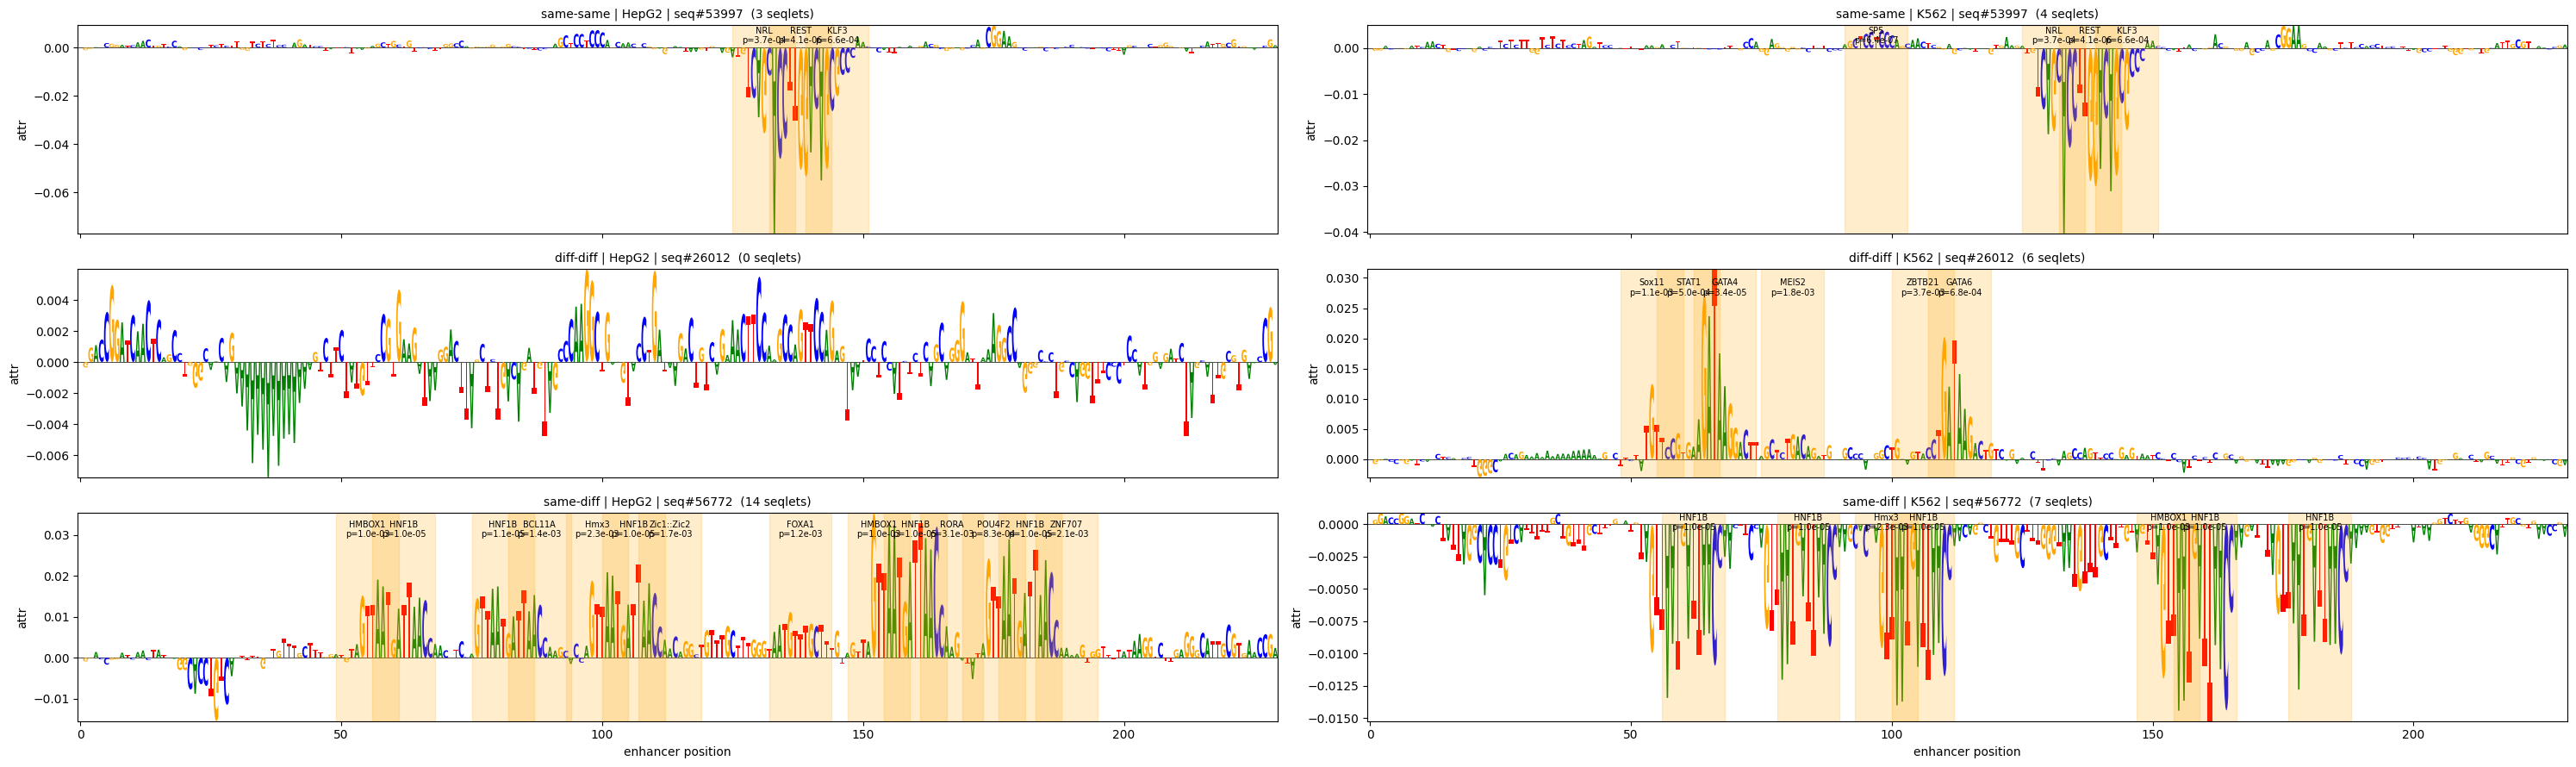


=== same-same | seq#53997 ===
  K562: 4 hits
    [132-144] REST(p=4.1e-06), SCAND3(p=1.4e-03), NR2F1(p=3.0e-03)  (enhancer)
    [125-137] NRL(p=3.7e-04), MAFF(p=8.3e-04), Mafb(p=1.6e-03)  (enhancer)
    [139-151] KLF3(p=6.6e-04), ZNF493(p=8.3e-04), TGIF1(p=1.6e-03)  (enhancer)
    [ 91-103] SP5(p=6.4e-07), ZNF263(p=1.8e-05), ZNF850(p=3.2e-04)  (enhancer)
  HepG2: 3 hits
    [132-144] REST(p=4.1e-06), SCAND3(p=1.4e-03), NR2F1(p=3.0e-03)  (enhancer)
    [125-137] NRL(p=3.7e-04), MAFF(p=8.3e-04), Mafb(p=1.6e-03)  (enhancer)
    [139-151] KLF3(p=6.6e-04), ZNF493(p=8.3e-04), TGIF1(p=1.6e-03)  (enhancer)

=== diff-diff | seq#26012 ===
  K562: 6 hits
    [ 62- 74] GATA4(p=3.4e-05), GATA2(p=8.3e-05), GATA6(p=4.5e-04)  (enhancer)
    [107-119] GATA6(p=6.8e-04), TRPS1(p=8.7e-04), Gata3(p=1.2e-03)  (enhancer)
    [ 55- 67] STAT1(p=5.0e-04), Stat5b(p=1.2e-03), Stat5a(p=1.3e-03)  (enhancer)
    [100-112] ZBTB21(p=3.7e-03), ZEB2(p=4.7e-03), ZEB1(p=5.1e-03)  (enhancer)
    [ 48- 60] Sox11(p=1.1e-03)

In [33]:
import logomaker as lm

# Tangermeme seqlet calling (tfmodisco-lite) + TOMTOM annotation,
# run only on the 3 example seqs by reusing precomputed attributions.

ENH_LEN = eigen_steering.ENHANCER_LEN
sub_idx = [reps[name] for name in ['same-same', 'diff-diff', 'same-diff']]

em_sub = EigenMap(model_names=CT, device=DEVICE)
em_sub.X = em.X[sub_idx]
em_sub.constructs = [em.constructs[i] for i in sub_idx]
em_sub.enhancers  = [em.enhancers[i]  for i in sub_idx] if hasattr(em, 'enhancers') else [''] * len(sub_idx)
for ct in CT:
    em_sub.attr[ct]       = em.attr[ct][sub_idx]
    em_sub.attr_hyp[ct]   = em.attr_hyp[ct][sub_idx]
    em_sub.importance[ct] = em.importance[ct][sub_idx]

em_sub.annotate_motifs(window_size=10, flank=1, pval_thresh=0.05, n_nearest=3)

fig, axes = plt.subplots(3, 2, figsize=(30, 9), sharex=True)
for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    seq_i = sub_idx[r]
    for c, ct in enumerate(['HepG2', 'K562']):
        ax = axes[r, c]
        att = em.attr[ct][seq_i, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax)
        _, ymax = ax.get_ylim()
        for h in em_sub.motif_hits[ct][r]:
            if h['start'] >= ENH_LEN:
                continue
            s, e = h['start'], min(h['end'], ENH_LEN)
            ax.axvspan(s, e, color='orange', alpha=0.20, zorder=0)
            ax.text((s + e) / 2, ymax * 0.95,
                    f"{h['tf']}\np={h['pval']:.1e}",
                    ha='center', va='top', fontsize=7, color='black')
        ax.set_title(f"{name} | {ct} | seq#{seq_i}  "
                     f"({len(em_sub.motif_hits[ct][r])} seqlets)", fontsize=10)
        ax.set_ylabel('attr')
axes[-1, 0].set_xlabel('enhancer position'); axes[-1, 1].set_xlabel('enhancer position')
plt.tight_layout(); plt.show()

for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    print(f'\n=== {name} | seq#{sub_idx[r]} ===')
    em_sub.show_motifs(seq_idx=r)

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DeepLIFT/SHAP: K562...
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt


  0%|          | 0/3150 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.0953, 0.0602, 0.1376, 0.1617, 0.2069, 0.2883, 0.1871, 0.3778, 0.1036,
        0.0643, 0.1963, 0.1620, 0.1449, 0.2200, 0.2112, 0.1257, 0.2238, 0.1243,
        0.1443, 0.1469, 0.0227, 0.2774, 0.0399, 0.1306, 0.2092, 0.1293, 0.2690,
        0.2529, 0.2558, 0.2997, 0.1015, 0.0551, 0.0682, 0.0443, 0.1886, 0.2122,
        0.2390, 0.0420, 0.0067, 0.2414, 0.0030, 0.1577, 0.2389, 0.0975, 0.0797,
        0.1537, 0.1117, 0.1108, 0.2208, 0.1679, 0.2973, 0.3231, 0.1778, 0.2425,
        0.1206, 0.1159, 0.2986, 0.1642, 0.0240, 0.0059, 0.1664, 0.1286, 0.2458,
        0.1322, 0.1912, 0.0286, 0.1877, 0.3195, 0.2057, 0.2001, 0.1589, 0.1946,
        0.2252, 0.3640, 0.2349, 0.3753, 0.2291, 0.0650, 0.1333, 0.0574, 0.1873,
        0.1304, 0.2349, 0.1325

DeepLIFT/SHAP: HepG2...
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt


  0%|          | 0/3150 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.1949, 0.3859, 0.1440, 0.3476, 0.1835, 0.0832, 0.0799, 0.1281, 0.1198,
        0.3533, 0.0713, 0.3216, 0.3193, 0.3372, 0.3025, 0.0805, 0.1738, 0.3735,
        0.2832, 0.4041, 0.0762, 0.3603, 0.1964, 0.7638, 0.3965, 0.1135, 0.2618,
        0.0392, 0.2278, 0.1515, 0.0219, 0.4898, 0.1597, 0.2387, 0.0657, 0.0544,
        0.0374, 0.3260, 0.0427, 0.3877, 0.1127, 0.4593, 0.1855, 0.4161, 0.3316,
        0.1305, 0.1847, 0.3853, 0.3830, 0.2880, 0.1597, 0.5763, 0.3261, 0.5392,
        0.4532, 0.6024, 0.2649, 0.2147, 0.1866, 0.4497, 0.3475, 0.0829, 0.2369,
        0.4597, 0.2103, 0.3213, 0.3272, 0.2158, 0.4133, 0.5619, 0.0685, 0.0318,
        0.5348, 0.5450, 0.3298, 0.3313, 0.6372, 0.3435, 0.1925, 0.1720, 0.2774,
        0.1597, 0.5196, 0.5283

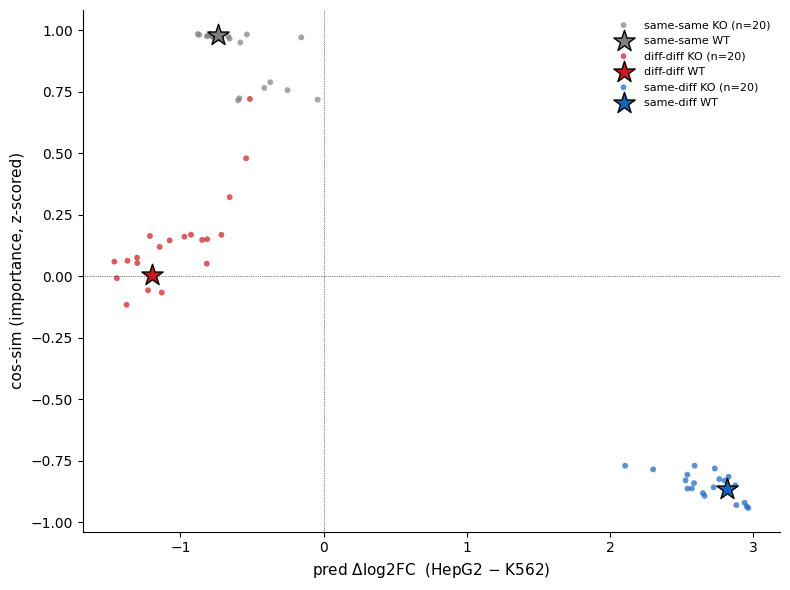

In [6]:
# --- knobs ---
N_REPS  = 20    # KO variants per seq
WIN     = 30    # contiguous KO window (bp), within enhancer
# -------------

# Random contiguous KOs the EigenMap-native way (like necessity_test,
# but at random windows instead of motif positions):
#   1. dinucleotide-shuffle the WHOLE WT seq -> background
#   2. for each variant, replace WT[s:s+W] with shuffle[s:s+W]
# Plot pred Δlog2FC vs cos-sim (importance, z-scored), WT marked.

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle

rng     = np.random.default_rng(0)
ENH_LEN = eigen_steering.ENHANCER_LEN  # 230
L       = em.X.shape[-1]               # 281

groups = list(reps.items())   # [('same-same', i), ('diff-diff', j), ('same-diff', k)]
all_X, tag = [], []
wt_pos = {}
for name, idx in groups:
    wt   = em.X[idx:idx+1].float()                                      # (1,4,L)
    shuf = dinuc_shuf(wt, n=N_REPS, random_state=int(idx))[0]           # (N_REPS,4,L)
    wt_pos[name] = sum(t.shape[0] for t in all_X)
    all_X.append(wt); tag.append(('WT', name))

    chim = wt.expand(N_REPS, -1, -1).clone()                            # (N_REPS,4,L)
    for k in range(N_REPS):
        s = int(rng.integers(0, ENH_LEN - WIN + 1))
        chim[k, :, s:s+WIN] = shuf[k, :, s:s+WIN]
    all_X.append(chim); tag += [('var', name)] * N_REPS

X = torch.cat(all_X, dim=0)   # (3 + 3*N_REPS, 4, L)

em_s = EigenMap(model_names=CT, device=DEVICE)
em_s.X         = X
em_s.constructs = [''] * X.shape[0]
em_s.enhancers  = [''] * X.shape[0]
em_s.compute_attributions(method='deeplift', n_shuffles=50, batch_size=128, verbose=True)

cs    = em_s.cosine_similarity(enhancer_only=True, mode='importance', zscore=True)
mdiff = em_s.predictions['HepG2'] - em_s.predictions['K562']

colors = {'same-same': '#7f7f7f', 'diff-diff': '#cb181d', 'same-diff': '#1565C0'}

fig, ax = plt.subplots(figsize=(8, 6))
for name, _ in groups:
    m = np.array([t == ('var', name) for t in tag])
    ax.scatter(mdiff[m], cs[m], s=18, c=colors[name],
               alpha=0.7, edgecolors='none', label=f'{name} KO (n={m.sum()})')
    w = wt_pos[name]
    ax.scatter([mdiff[w]], [cs[w]], s=260, c=colors[name],
               marker='*', edgecolors='black', linewidths=1.0,
               label=f'{name} WT', zorder=5)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('pred $\\Delta$log2FC  (HepG2 $-$ K562)', fontsize=11)
ax.set_ylabel('cos-sim (importance, z-scored)', fontsize=11)
ax.legend(fontsize=8, frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DeepLIFT/SHAP: K562...
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt


  0%|          | 0/6060 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.0048, 0.1338, 0.3083, 0.0033, 0.4491, 0.2579, 0.2134, 0.2155, 0.1846,
        0.3005, 0.1415, 0.0013, 0.2431, 0.1186, 0.1309, 0.3106, 0.0514, 0.5312,
        0.0402, 0.1078, 0.1608, 0.0416, 0.2031, 0.3539, 0.1106, 0.1605, 0.0765,
        0.0645, 0.2074, 0.3816, 0.0111, 0.1473, 0.1812, 0.0662, 0.1172, 0.0515,
        0.2372, 0.1604, 0.1586, 0.4123, 0.0314, 0.3002, 0.1128, 0.0111, 0.2608,
        0.0761, 0.0246, 0.1988, 0.1636, 0.1688, 0.1775, 0.1694, 0.0410, 0.2747,
        0.0086, 0.2132, 0.1390, 0.1221, 0.1846, 0.3468, 0.2003, 0.0614, 0.1385,
        0.1528, 0.0788, 0.2236, 0.2167, 0.0028, 0.0212, 0.2357, 0.1404, 0.0182,
        0.2006, 0.0839, 0.2041, 0.0285, 0.3869, 0.1308, 0.0678, 0.1625, 0.3213,
        0.2126, 0.2505, 0.1449

DeepLIFT/SHAP: HepG2...
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt


  0%|          | 0/6060 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.4511e+00, 5.4229e-01, 1.2108e-01, 8.1732e-02, 1.4833e-01, 7.4439e-02,
        2.1783e-01, 4.8672e-01, 4.3866e-01, 2.1425e-01, 6.4127e-02, 4.4470e-01,
        3.2844e-01, 1.1044e-01, 6.3435e-01, 9.6589e-02, 2.9432e-01, 1.0156e-01,
        1.2049e-01, 5.1267e-01, 4.6741e-01, 2.7461e-01, 7.0944e-02, 3.2782e-01,
        3.7603e-01, 5.0543e-01, 2.9031e-01, 1.2069e-01, 1.9806e-01, 5.0023e-01,
        2.8974e-02, 4.3944e-01, 6.3772e-02, 4.1181e-01, 2.0816e-01, 2.0028e-01,
        2.8174e-01, 3.6411e-01, 1.1204e-01, 4.7002e-01, 4.1913e-01, 4.2347e-01,
        2.8020e-01, 4.7175e-01, 1.8570e-01, 2.5937e-01, 2.3817e-01, 3.5332e-01,
        1.3930e-01, 2.2242e-01, 3.8370e-01, 1.2317e-01, 2.6375e-02, 1.8776e-01,
        3.8762e-01, 2.7590e-01

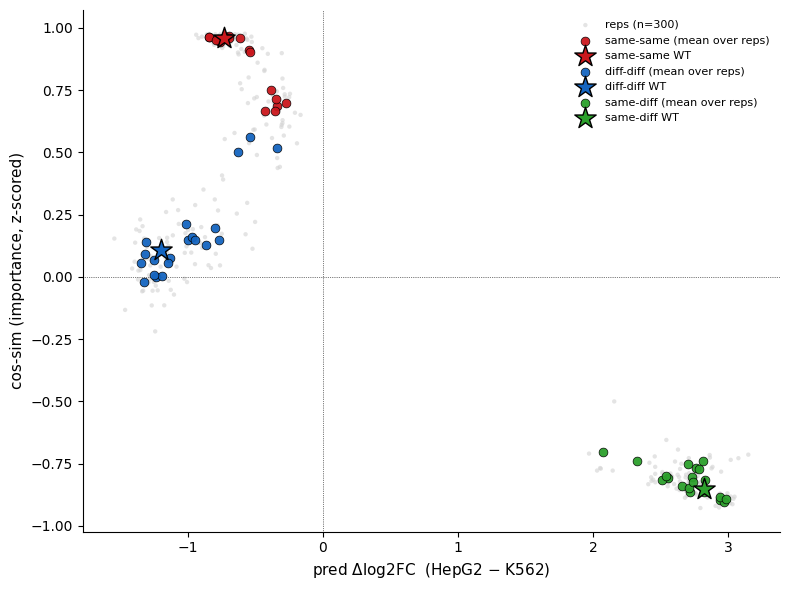

In [7]:
# --- knobs ---
N_KO    = 20    # KO positions (random windows) per seq
N_REPS  = 5    # shuffle replicates per KO position (gray cloud size per dot)
WIN     = 30    # contiguous KO window (bp), within enhancer
# -------------

# Same KO mechanism as necessity_test: dinuc-shuffle the WT, replace WT[s:s+W]
# with the shuffled segment. For each KO window we run N_REPS shuffles -> gray
# cloud; the colored dot per window is the mean over its N_REPS replicates.

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle

rng     = np.random.default_rng(0)
ENH_LEN = eigen_steering.ENHANCER_LEN
L       = em.X.shape[-1]

groups = list(reps.items())   # [('same-same', i), ('diff-diff', j), ('same-diff', k)]
all_X = []
tag   = []   # ('WT', name, -1) | ('var', name, ki)
wt_pos = {}
for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    wt_pos[name] = sum(t.shape[0] for t in all_X)
    all_X.append(wt); tag.append(('WT', name, -1))

    starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_KO)
    for ki, s in enumerate(starts):
        shuf = dinuc_shuf(wt, n=N_REPS,
                          random_state=int(idx) * 1000 + int(ki))[0]   # (N_REPS,4,L)
        chim = wt.expand(N_REPS, -1, -1).clone()
        chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
        all_X.append(chim)
        tag += [('var', name, int(ki))] * N_REPS

X = torch.cat(all_X, dim=0)   # (3 + 3*N_KO*N_REPS, 4, L)

em_s = EigenMap(model_names=CT, device=DEVICE)
em_s.X         = X
em_s.constructs = [''] * X.shape[0]
em_s.enhancers  = [''] * X.shape[0]
em_s.compute_attributions(method='deeplift', n_shuffles=20, batch_size=256, verbose=True)

cs    = em_s.cosine_similarity(enhancer_only=True, mode='importance', zscore=True)
mdiff = em_s.predictions['HepG2'] - em_s.predictions['K562']

colors = {'same-same': '#cb181d',  # red
          'diff-diff': '#1565C0',  # blue
          'same-diff': '#2ca02c'}  # green

fig, ax = plt.subplots(figsize=(8, 6))

# 1) gray cloud: every individual replicate
var_mask = np.array([t[0] == 'var' for t in tag])
ax.scatter(mdiff[var_mask], cs[var_mask], s=10, c='lightgray',
           alpha=0.6, edgecolors='none', label=f'reps (n={var_mask.sum()})',
           rasterized=True, zorder=1)

# 2) per-window mean dot, colored by group
for name, _ in groups:
    xs, ys = [], []
    for ki in range(N_KO):
        m = np.array([t == ('var', name, ki) for t in tag])
        if m.any():
            xs.append(mdiff[m].mean()); ys.append(cs[m].mean())
    ax.scatter(xs, ys, s=40, c=colors[name],
               alpha=0.95, edgecolors='black', linewidths=0.5,
               label=f'{name} (mean over reps)', zorder=3)
    w = wt_pos[name]
    ax.scatter([mdiff[w]], [cs[w]], s=260, c=colors[name],
               marker='*', edgecolors='black', linewidths=1.0,
               label=f'{name} WT', zorder=5)

ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('pred $\\Delta$log2FC  (HepG2 $-$ K562)', fontsize=11)
ax.set_ylabel('cos-sim (importance, z-scored)', fontsize=11)
ax.legend(fontsize=8, frameon=False, loc='best')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

same-same HepG2: winners = [41, 143, 142, 129, 130, 126, 137, 142, 139, 129, 139, 141, 167, 136, 131, 135, 137, 131, 134, 131, 137, 143, 139, 136, 144, 139, 133, 141, 137, 138, 131, 139, 139, 142, 136, 145, 126, 139, 132, 140, 141, 144, 141, 138, 135, 144, 140, 133, 129, 36]
same-same K562: winners = [119, 143, 142, 129, 136, 126, 137, 142, 139, 129, 139, 141, 175, 136, 131, 135, 137, 131, 134, 142, 137, 143, 139, 136, 144, 139, 133, 141, 137, 138, 131, 138, 139, 142, 136, 145, 126, 139, 132, 140, 141, 144, 141, 138, 135, 144, 140, 133, 129, 125]
diff-diff HepG2: winners = [34, 107, 223, 37, 37, 35, 33, 114, 92, 36, 109, 37, 92, 36, 37, 34, 34, 107, 39, 36, 39, 138, 109, 38, 34, 114, 34, 38, 36, 107, 35, 107, 107, 92, 38, 92, 37, 34, 36, 114, 37, 111, 108, 39, 204, 35, 34, 38, 110, 107]
diff-diff K562: winners = [109, 63, 66, 68, 66, 52, 55, 114, 114, 63, 66, 69, 67, 64, 109, 106, 63, 112, 63, 69, 64, 111, 65, 65, 65, 66, 111, 63, 114, 65, 65, 107, 68, 60, 65, 61, 66, 168, 61, 109, 64,

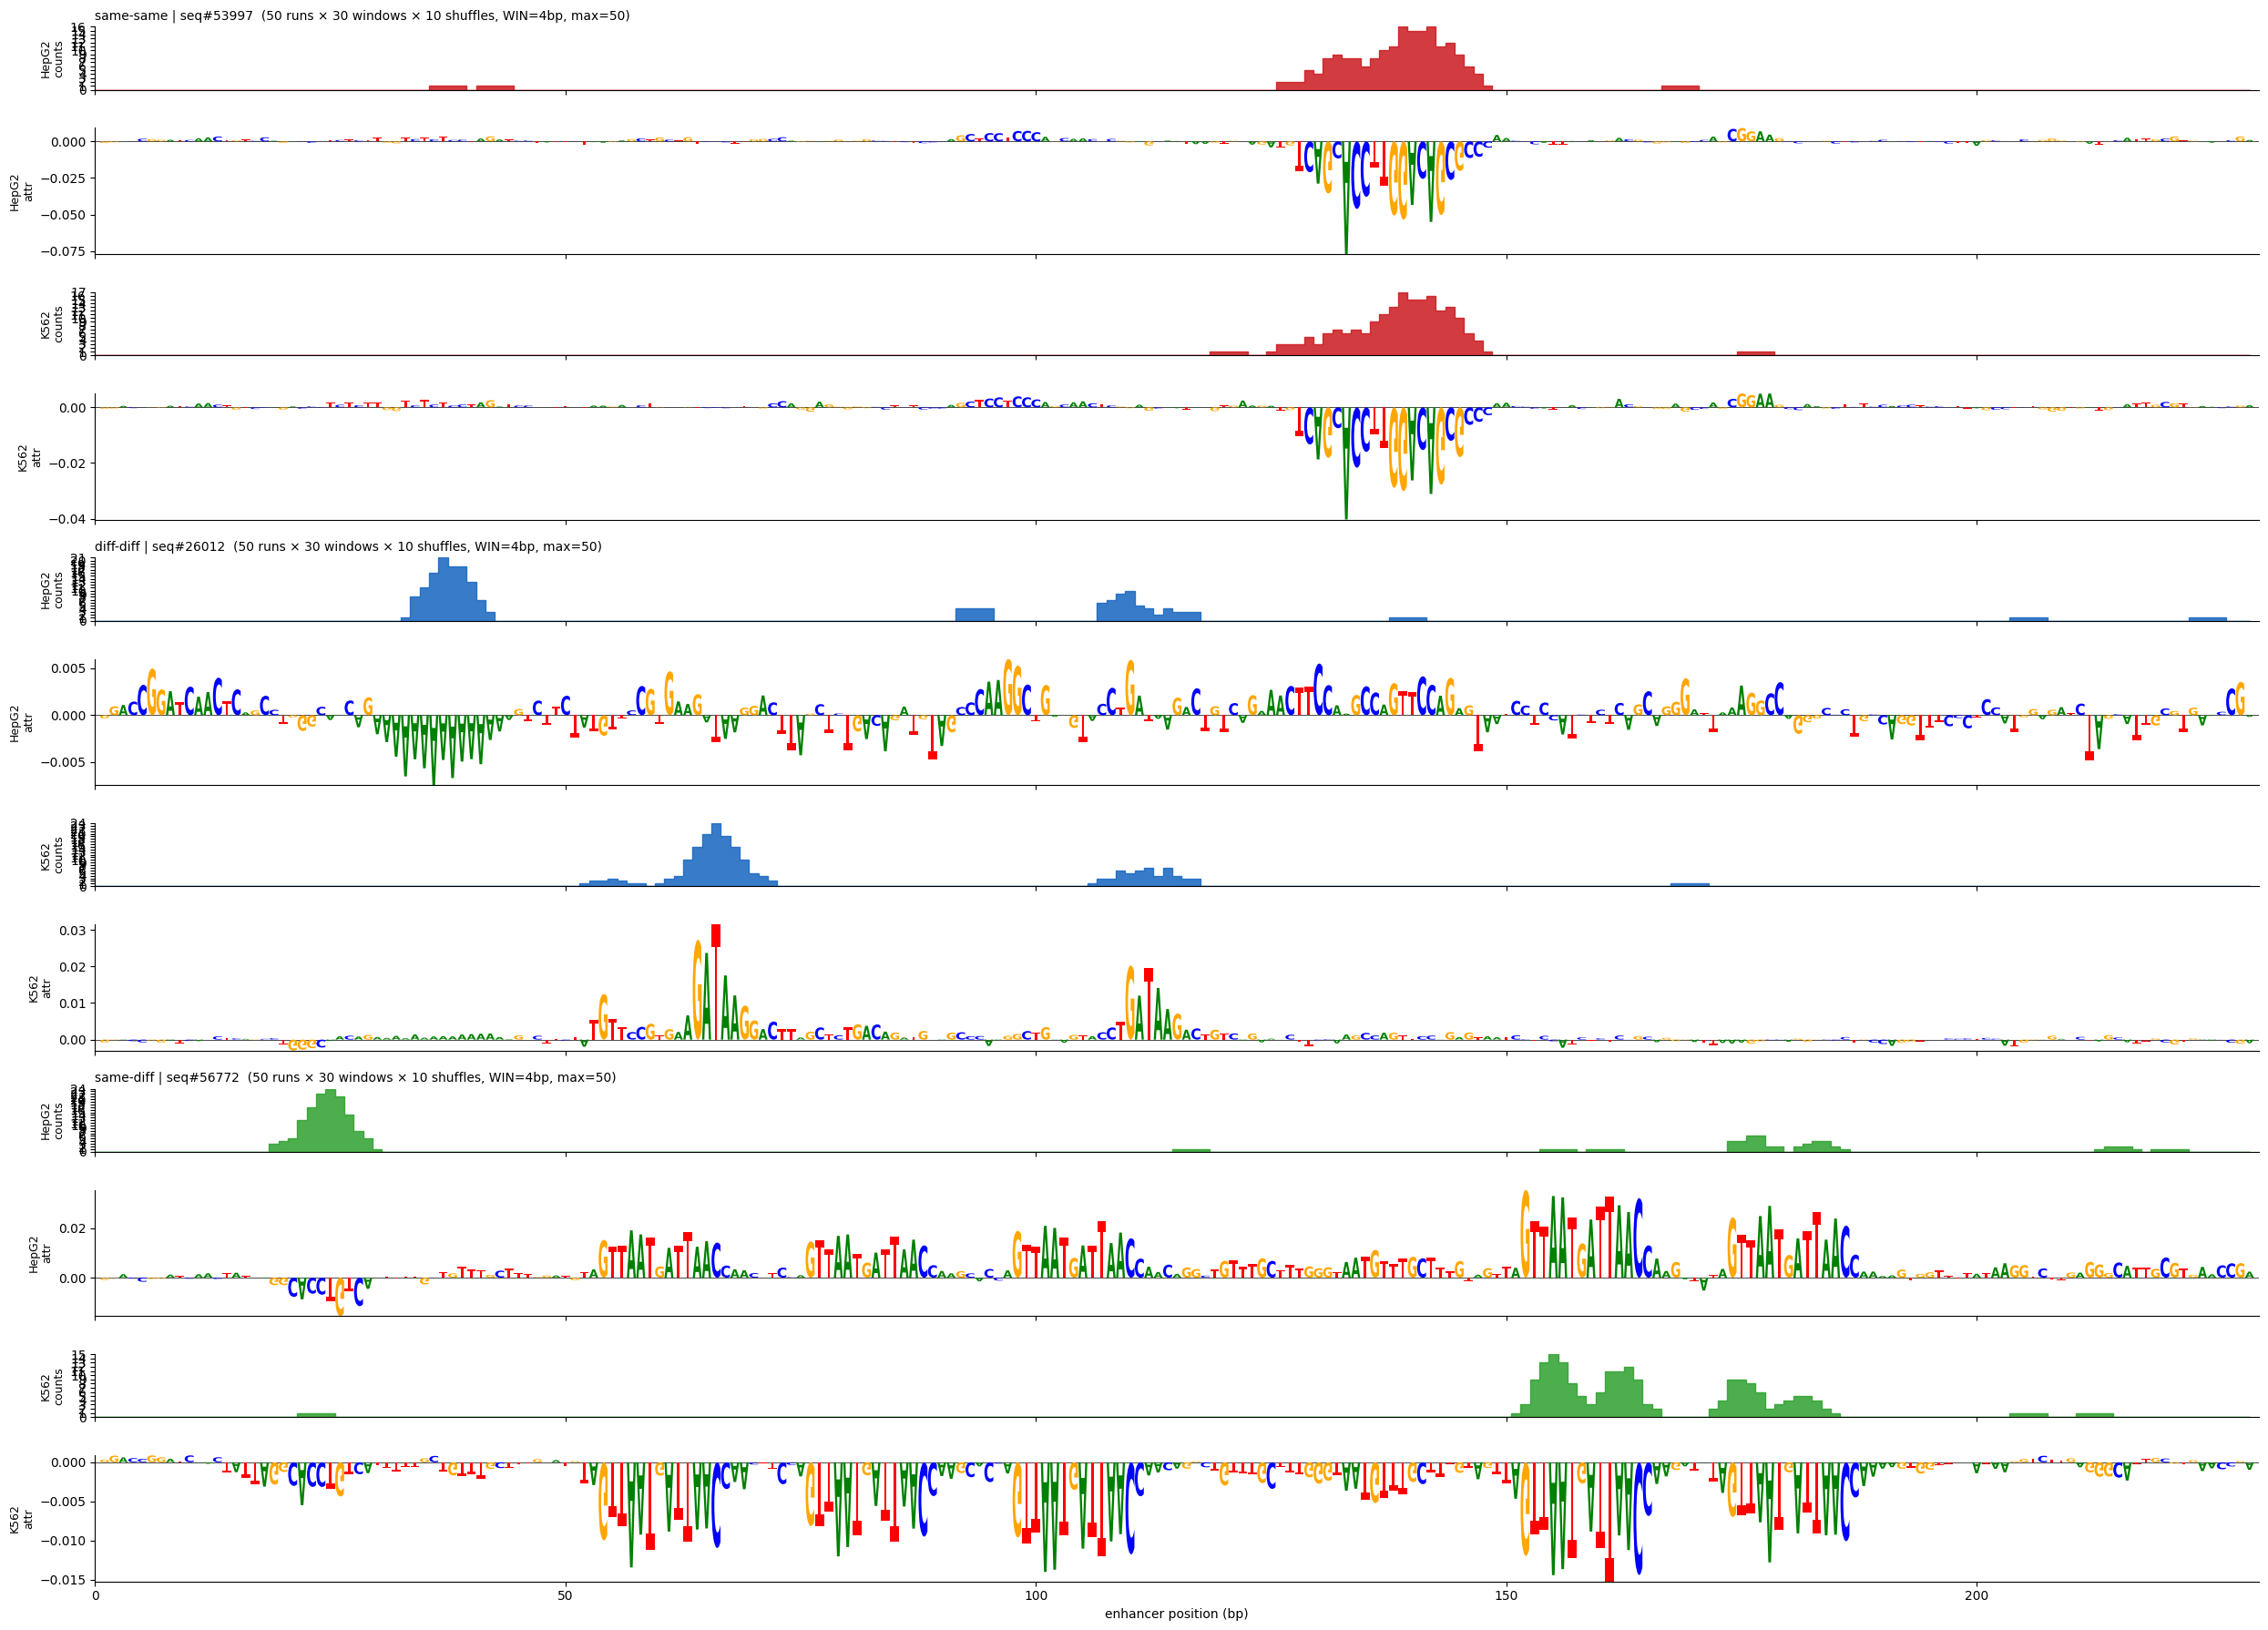

In [37]:
import logomaker as lm

# --- knobs ---
N_RUNS = 50   # independent screen runs per seq
N_TRY  = 30   # random windows tested per run 50*4 = 200/230
N_REPS = 10   # dinuc-shuffle replicates per window (averaged before scoring)
WIN    = 4    # KO window size (bp)
# -------------

# Necessity-style screen with selection, scored separately per cell type.
# Per run, per cell type:
#   - sample N_TRY random windows in the enhancer
#   - for each window: dinuc-shuffle the WT N_REPS times, splice into WT
#   - score = |mean Δpred|  (that cell type only)
#   - winner = window with max score
# Per-nucleotide raw count = # of runs whose winning [s, s+WIN] covers each position.
# Max possible per position = N_RUNS.

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle
ENH_LEN = eigen_steering.ENHANCER_LEN
L       = em.X.shape[-1]
rng     = np.random.default_rng(42)

groups  = list(reps.items())
CTS     = ['HepG2', 'K562']
winners = {name: {ct: [] for ct in CTS} for name, _ in groups}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    wt_pred = em._predict_tensor(wt, models=models, batch_size=4)
    wt_p = {ct: float(wt_pred[ct][0]) for ct in CTS}

    for run_i in range(N_RUNS):
        starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
        chunks = []
        for s in starts:
            shuf = dinuc_shuf(wt, n=N_REPS,
                              random_state=int(idx)*1_000_000
                              + run_i*1000 + int(s))[0]                 # (N_REPS,4,L)
            chim = wt.expand(N_REPS, -1, -1).clone()
            chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
            chunks.append(chim)
        all_chim = torch.cat(chunks, dim=0)                             # (N_TRY*N_REPS,4,L)
        p = em._predict_tensor(all_chim, models=models, batch_size=128)
        for ct in CTS:
            pm = p[ct].reshape(N_TRY, N_REPS).mean(axis=1)
            impact = np.abs(pm - wt_p[ct])
            winners[name][ct].append(int(starts[int(impact.argmax())]))
    for ct in CTS:
        winners[name][ct] = np.array(winners[name][ct])
        print(f'{name} {ct}: winners = {winners[name][ct].tolist()}')

def coverage_counts(starts_arr, win, length):
    """Raw count: # of runs whose winning [s, s+win] covers each position."""
    cov = np.zeros(length, dtype=int)
    for s in starts_arr:
        cov[s:s+win] += 1
    return cov

# --- plot: per seq -> [HepG2 counts, HepG2 logo, K562 counts, K562 logo] ---
group_color = {'same-same': '#cb181d', 'diff-diff': '#1565C0', 'same-diff': '#2ca02c'}
n_seqs   = len(groups)
ROWS_PER = 4
xs = np.arange(ENH_LEN)

fig, axes = plt.subplots(ROWS_PER * n_seqs, 1,
                         figsize=(25, 3 * ROWS_PER * n_seqs / 2),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1, 2] * n_seqs})

for gi, (name, idx) in enumerate(groups):
    base = gi * ROWS_PER
    col  = group_color[name]
    for ci, ct in enumerate(CTS):

        ax_d = axes[base + 2*ci]
        ax_l = axes[base + 2*ci + 1]

        d = coverage_counts(winners[name][ct], WIN, ENH_LEN)
        ax_d.fill_between(xs, d, 0, color=col, alpha=0.85, step='mid')
        ax_d.set_ylim(0, max(int(d.max()), 1))
        ax_d.set_yticks(np.arange(0, max(int(d.max()), 1) + 1))
        ax_d.set_ylabel(f'{ct}\ncounts', fontsize=9)
        if ci == 0:
            ax_d.set_title(f'{name} | seq#{idx}  '
                           f'({N_RUNS} runs × {N_TRY} windows × {N_REPS} shuffles, WIN={WIN}bp, max={N_RUNS})',
                           fontsize=10, loc='left')
        for sp in ('top', 'right'): ax_d.spines[sp].set_visible(False)

        att = em.attr[ct][idx, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax_l)
        ax_l.set_ylabel(f'{ct}\nattr', fontsize=9)
        for sp in ('top', 'right'): ax_l.spines[sp].set_visible(False)

axes[-1].set_xlabel('enhancer position (bp)')
axes[-1].set_xlim(0, ENH_LEN)
plt.tight_layout(); plt.show()

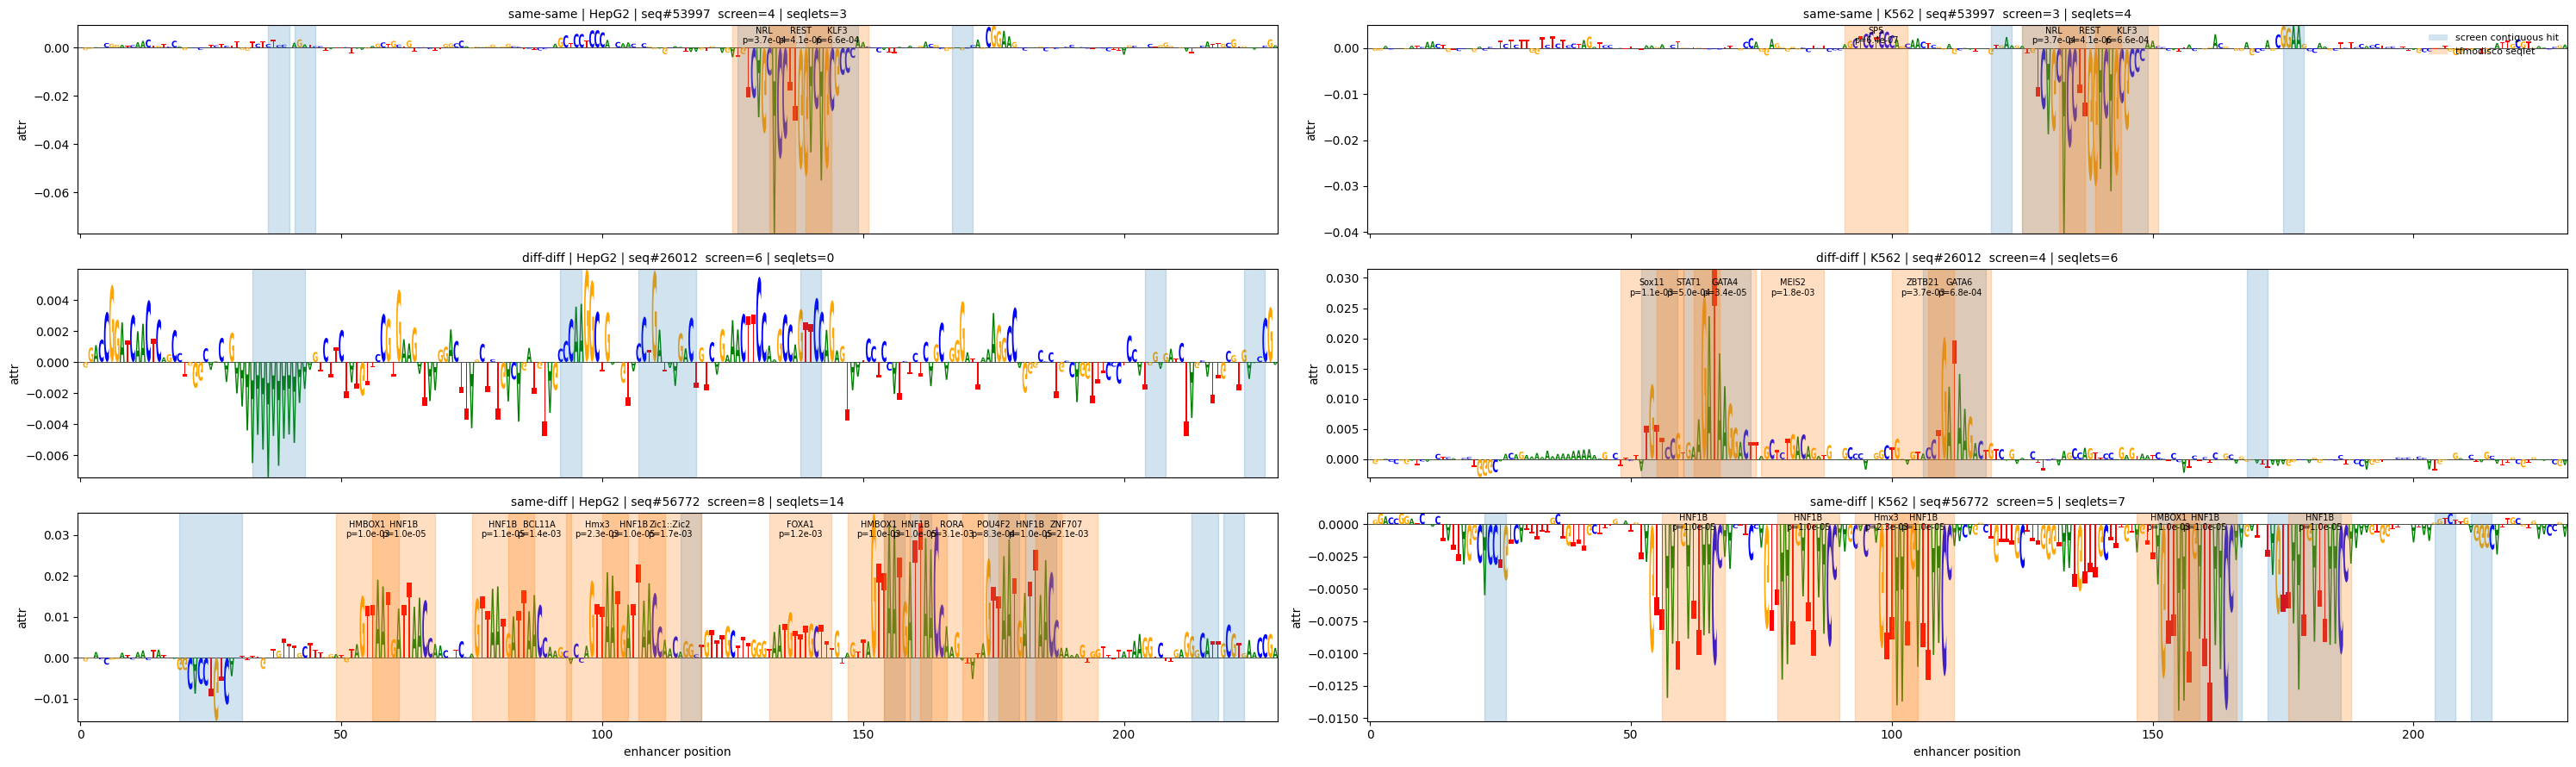

In [40]:
import logomaker as lm
from matplotlib.patches import Patch

# Overlay screen-derived contiguous "hits" (any non-zero count stretch)
# and tangermeme tfmodisco seqlets on the 6 attribution logos.
#   blue   span = screen-derived contiguous region
#   orange span = tfmodisco seqlet (from em_sub.motif_hits)

ENH_LEN = eigen_steering.ENHANCER_LEN
SCREEN_COLOR  = '#1f77b4'  # blue
SEQLET_COLOR  = '#ff7f0e'  # orange

def contiguous_regions(counts):
    """Yield (start, end) for every contiguous run of >0 counts."""
    in_run = False
    s = 0
    for i, v in enumerate(counts):
        if v > 0 and not in_run:
            s = i; in_run = True
        elif v == 0 and in_run:
            yield (s, i); in_run = False
    if in_run:
        yield (s, len(counts))

fig, axes = plt.subplots(3, 2, figsize=(30, 9), sharex=True)
for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    seq_i = sub_idx[r]   # from cell 901f5c23
    for c, ct in enumerate(['HepG2', 'K562']):
        ax = axes[r, c]
        att = em.attr[ct][seq_i, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax)
        _, ymax = ax.get_ylim()

        d = coverage_counts(winners[name][ct], WIN, ENH_LEN)
        screen_regions = list(contiguous_regions(d))
        for (s, e) in screen_regions:
            ax.axvspan(s, e, color=SCREEN_COLOR, alpha=0.20, zorder=0)

        seqlet_hits = [h for h in em_sub.motif_hits[ct][r] if h['start'] < ENH_LEN]
        for h in seqlet_hits:
            s, e = h['start'], min(h['end'], ENH_LEN)
            ax.axvspan(s, e, color=SEQLET_COLOR, alpha=0.25, zorder=0)
            ax.text((s + e) / 2, ymax * 0.95,
                    f"{h['tf']}\np={h['pval']:.1e}",
                    ha='center', va='top', fontsize=7, color='black')

        ax.set_title(f"{name} | {ct} | seq#{seq_i}  "
                     f"screen={len(screen_regions)} | seqlets={len(seqlet_hits)}",
                     fontsize=10)
        ax.set_ylabel('attr')

axes[0, 1].legend(handles=[
    Patch(facecolor=SCREEN_COLOR, alpha=0.20, label='screen contiguous hit'),
    Patch(facecolor=SEQLET_COLOR, alpha=0.25, label='tfmodisco seqlet'),
], loc='upper right', fontsize=8, frameon=False)

axes[-1, 0].set_xlabel('enhancer position'); axes[-1, 1].set_xlabel('enhancer position')
plt.tight_layout(); plt.show()

same-same HepG2 k-cee: cov=35bp, delta_mean=-1.227, per_bp_mean=-0.0351
same-same HepG2 modisco: cov=26bp, delta_mean=-1.287, per_bp_mean=-0.0495
same-same K562 k-cee: cov=32bp, delta_mean=-0.789, per_bp_mean=-0.0246
same-same K562 modisco: cov=38bp, delta_mean=-0.585, per_bp_mean=-0.0154
diff-diff HepG2 k-cee: cov=37bp, delta_mean=-0.077, per_bp_mean=-0.0021
diff-diff K562 k-cee: cov=36bp, delta_mean=+0.808, per_bp_mean=+0.0225
diff-diff K562 modisco: cov=57bp, delta_mean=+0.790, per_bp_mean=+0.0139
same-diff HepG2 k-cee: cov=45bp, delta_mean=+0.694, per_bp_mean=+0.0154
same-diff HepG2 modisco: cov=123bp, delta_mean=+3.115, per_bp_mean=+0.0253
same-diff K562 k-cee: cov=42bp, delta_mean=-0.061, per_bp_mean=-0.0015
same-diff K562 modisco: cov=74bp, delta_mean=-0.287, per_bp_mean=-0.0039


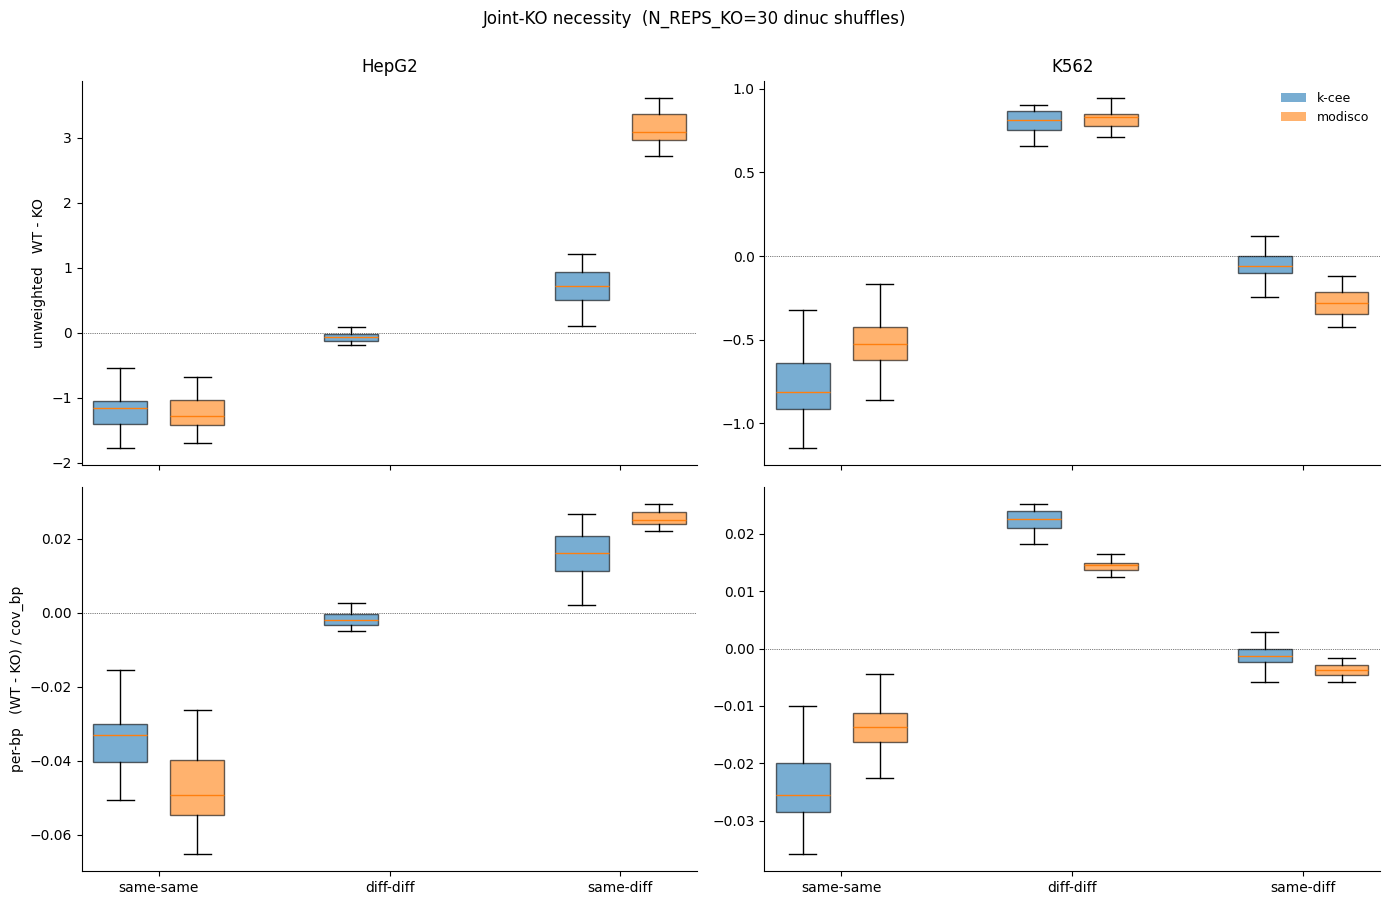

In [41]:
# Joint-KO necessity: shuffle ALL annotated regions per (seq, ct) at once,
# compare k-cee screen contiguous hits vs tfmodisco seqlets.
# Two scores per replicate:
#   - delta   = WT - KO            (unweighted, total necessity)
#   - per_bp  = (WT - KO) / cov_bp (weighted by coverage -> per-bp necessity)

# --- knobs ---
N_REPS_KO = 30   # dinuc-shuffle replicates -> distribution per box
# -------------

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle
ENH_LEN = eigen_steering.ENHANCER_LEN
L       = em.X.shape[-1]

def merge_intervals(intervals):
    if not intervals: return []
    iv = sorted(intervals)
    out = [list(iv[0])]
    for s, e in iv[1:]:
        if s <= out[-1][1]:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [tuple(x) for x in out]

def annotations_for(name, r, ct, method):
    if method == 'k-cee':
        d = coverage_counts(winners[name][ct], WIN, ENH_LEN)
        return list(contiguous_regions(d))
    elif method == 'modisco':
        return [(h['start'], min(h['end'], ENH_LEN))
                for h in em_sub.motif_hits[ct][r] if h['start'] < ENH_LEN]
    raise ValueError(method)

records = []
for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    seq_i = sub_idx[r]
    wt = em.X[seq_i:seq_i+1].float()
    wt_pred = em._predict_tensor(wt, models=models, batch_size=4)
    wt_p = {ct: float(wt_pred[ct][0]) for ct in CTS}

    for ct in CTS:
        for method in ['k-cee', 'modisco']:
            regions = merge_intervals(annotations_for(name, r, ct, method))
            cov_bp = sum(e - s for s, e in regions)
            if cov_bp == 0:
                continue
            shuf = dinuc_shuf(wt, n=N_REPS_KO,
                              random_state=int(seq_i)*97 + hash(method) % 1000)[0]
            chim = wt.expand(N_REPS_KO, -1, -1).clone()
            for s, e in regions:
                chim[:, :, s:e] = shuf[:, :, s:e]
            p = em._predict_tensor(chim, models=models, batch_size=128)
            deltas = wt_p[ct] - p[ct]
            for d_v in deltas:
                records.append({
                    'group': name, 'ct': ct, 'method': method,
                    'cov_bp': cov_bp,
                    'delta': float(d_v),
                    'per_bp': float(d_v) / cov_bp,
                })
            print(f'{name} {ct} {method}: cov={cov_bp}bp, '
                  f'delta_mean={deltas.mean():+.3f}, per_bp_mean={(deltas / cov_bp).mean():+.4f}')

df_rec = pd.DataFrame(records)

# --- box plot: unweighted (top) + per-bp (bottom), facet by ct ---
method_color = {'k-cee': '#1f77b4', 'modisco': '#ff7f0e'}
xs_order = ['same-same', 'diff-diff', 'same-diff']
methods = ['k-cee', 'modisco']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')
for row, (ycol, ylab) in enumerate([('delta', 'unweighted   WT - KO'),
                                     ('per_bp', 'per-bp   (WT - KO) / cov_bp')]):
    for ci, ct in enumerate(CTS):
        ax = axes[row, ci]
        sub = df_rec[df_rec['ct'] == ct]
        positions, box_data, box_colors, xticks_pos = [], [], [], []
        for gi, g in enumerate(xs_order):
            for mi, m in enumerate(methods):
                vals = sub[(sub['group'] == g) & (sub['method'] == m)][ycol].values
                if len(vals) == 0:
                    continue
                pos = gi * (len(methods) + 1) + mi
                positions.append(pos); box_data.append(vals); box_colors.append(method_color[m])
            xticks_pos.append(gi * (len(methods) + 1) + (len(methods) - 1) / 2)

        bp = ax.boxplot(box_data, positions=positions, widths=0.7,
                        patch_artist=True, showfliers=False)
        for patch, c in zip(bp['boxes'], box_colors):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        ax.axhline(0, color='k', lw=0.5, ls=':')
        ax.set_xticks(xticks_pos); ax.set_xticklabels(xs_order)
        if row == 0:
            ax.set_title(ct)
        if ci == 0:
            ax.set_ylabel(ylab)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

from matplotlib.patches import Patch
axes[0, -1].legend(handles=[Patch(facecolor=method_color[m], alpha=0.6, label=m) for m in methods],
                   loc='upper right', fontsize=9, frameon=False)
plt.suptitle(f'Joint-KO necessity  (N_REPS_KO={N_REPS_KO} dinuc shuffles)', y=1.00)
plt.tight_layout(); plt.show()

  [skip] diff-diff HepG2 modisco: 0 regions
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DeepLIFT/SHAP: K562...
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt


  0%|          | 0/5560 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.4385, 0.2590, 0.2956, 0.2987, 0.1589, 0.1426, 0.2064, 0.1520, 0.0735,
        0.0702, 0.2062, 0.1155, 0.1530, 0.1504, 0.2738, 0.0286, 0.1621, 0.0449,
        0.2303, 0.0510, 0.2789, 0.3166, 0.2961, 0.2621, 0.4027, 0.1790, 0.4311,
        0.4119, 0.4853, 0.0084, 0.4714, 0.0513, 0.4772, 0.2814, 0.4606, 0.4894,
        0.3074, 0.5505, 0.2598, 0.4100, 0.4721, 0.4933, 0.2511, 0.3799, 0.6126,
        0.3623, 0.3100, 0.2763, 0.4011, 0.1209, 0.0757, 0.5059, 0.1180, 0.1943,
        0.5021, 0.0917, 0.5228, 0.5315, 0.6016, 0.1289, 0.1393, 0.2683, 0.2066,
        0.1966, 0.3265, 0.0648, 0.2644, 0.2255, 0.1629, 0.0482, 0.2349, 0.2177,
        0.2940, 0.3040, 0.1727, 0.1948, 0.0880, 0.3370, 0.0767, 0.2101, 0.3477,
        0.3717, 0.2524, 0.4230

DeepLIFT/SHAP: HepG2...
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt


  0%|          | 0/5560 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.2656, 0.3682, 0.1437, 0.3591, 0.1431, 0.0560, 0.2599, 0.2731, 0.0939,
        0.1395, 0.1562, 0.2052, 0.3005, 0.3096, 0.3674, 0.5753, 0.0169, 0.1537,
        0.1221, 0.5465, 0.5805, 0.7275, 0.6724, 0.6220, 0.6368, 0.5968, 0.3430,
        0.1783, 0.4938, 0.4571, 0.5209, 0.4367, 0.0878, 0.8420, 0.4377, 0.4087,
        0.7304, 0.5153, 0.7830, 0.6178, 0.7308, 0.2895, 0.3180, 0.5365, 0.3613,
        0.5752, 0.5006, 0.0770, 0.5525, 0.4749, 0.5121, 0.5981, 0.2862, 0.3717,
        0.3314, 0.4842, 0.4475, 0.4203, 0.1726, 0.4295, 0.6613, 0.6688, 0.8103,
        0.7079, 0.2215, 0.8997, 0.2792, 0.6053, 0.6928, 0.7755, 0.7649, 0.6531,
        0.7515, 0.2505, 0.7112, 0.4307, 0.7573, 0.5056, 0.2621, 0.7906, 0.2927,
        0.3638, 0.4348, 0.5037

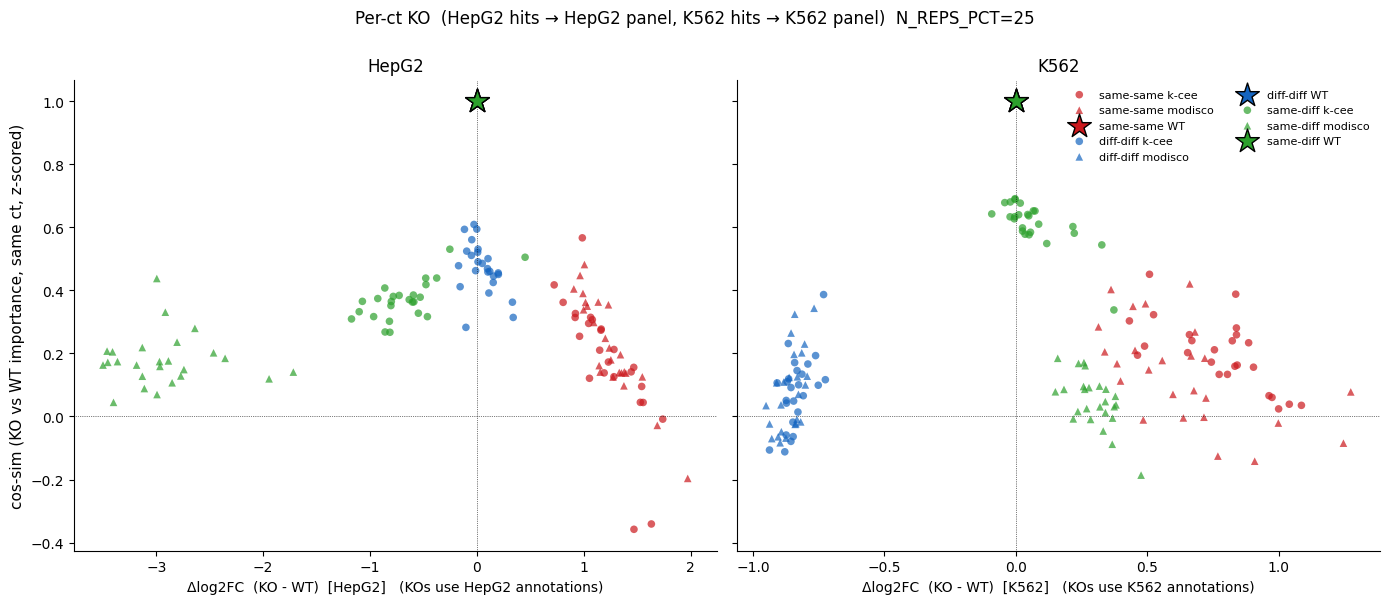

In [46]:
# Per-cell-line scoring with per-cell-line KOs:
# when plotting HepG2, only HepG2-annotated regions are shuffled;
# when plotting K562,  only K562-annotated regions are shuffled.
# y-axis = cos-sim (KO vs WT importance, same ct, z-scored)

# --- knobs ---
N_REPS_PCT = 25
# -------------

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle
ENH_LEN = eigen_steering.ENHANCER_LEN

# Build batch: WTs once + per-(seq, ct, method) chimeras
all_X2, tag2 = [], []   # tag2: ('WT', name) | ('KO', name, ct, method)
wt_pos2 = {}
for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    seq_i = sub_idx[r]
    wt = em.X[seq_i:seq_i+1].float()
    wt_pos2[name] = sum(t.shape[0] for t in all_X2)
    all_X2.append(wt); tag2.append(('WT', name))

    for ct_anno in CTS:
        for method in ['k-cee', 'modisco']:
            regs = merge_intervals(annotations_for(name, r, ct_anno, method))
            if not regs:
                print(f'  [skip] {name} {ct_anno} {method}: 0 regions')
                continue
            shuf = dinuc_shuf(wt, n=N_REPS_PCT,
                              random_state=int(seq_i)*173 + (hash(method) + hash(ct_anno)) % 1000)[0]
            chim = wt.expand(N_REPS_PCT, -1, -1).clone()
            for s, e in regs:
                chim[:, :, s:e] = shuf[:, :, s:e]
            all_X2.append(chim)
            tag2 += [('KO', name, ct_anno, method)] * N_REPS_PCT

X2 = torch.cat(all_X2, dim=0)
em_kp = EigenMap(model_names=CT, device=DEVICE)
em_kp.X = X2
em_kp.constructs = [''] * X2.shape[0]
em_kp.enhancers  = [''] * X2.shape[0]
em_kp.compute_attributions(method='deeplift', n_shuffles=20, batch_size=128, verbose=True)

def cos_to_wt2(ct, name):
    imp_all = em_kp.importance[ct][:, :ENH_LEN]
    wt_imp  = imp_all[wt_pos2[name]]
    a = _zscore(imp_all); b = _zscore(wt_imp)
    a /= (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-12)
    b /= (np.linalg.norm(b) + 1e-12)
    return a @ b

wt_pred_ct2 = {name: {ct: float(em_kp.predictions[ct][wt_pos2[name]]) for ct in CTS}
               for name in ['same-same', 'diff-diff', 'same-diff']}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ci, ct in enumerate(CTS):
    ax = axes[ci]
    cs_wt = cos_to_wt2(ct, name=None) if False else None  # per-name below
    for name in ['same-same', 'diff-diff', 'same-diff']:
        col = group_color[name]
        cs_wt = cos_to_wt2(ct, name)
        for method in ['k-cee', 'modisco']:
            # match KOs that were built with THIS ct's annotations
            m = np.array([t == ('KO', name, ct, method) for t in tag2])
            if not m.any():
                continue
            dx = em_kp.predictions[ct][m] - wt_pred_ct2[name][ct]
            dy = cs_wt[m]
            ax.scatter(dx, dy, s=30, c=col,
                       marker=method_marker[method], alpha=0.7,
                       edgecolors='none', label=f'{name} {method}')
        ax.scatter([0], [1.0], s=320, c=col, marker='*',
                   edgecolors='black', linewidths=1.0, zorder=5,
                   label=f'{name} WT')
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.set_xlabel(f'Δlog2FC  (KO - WT)  [{ct}]   (KOs use {ct} annotations)', fontsize=10)
    if ci == 0:
        ax.set_ylabel('cos-sim (KO vs WT importance, same ct, z-scored)', fontsize=11)
    ax.set_title(ct)
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

axes[-1].legend(fontsize=8, frameon=False, loc='best', ncol=2)
plt.suptitle(f'Per-ct KO  (HepG2 hits → HepG2 panel, K562 hits → K562 panel)  '
             f'N_REPS_PCT={N_REPS_PCT}', y=1.00)
plt.tight_layout(); plt.show()

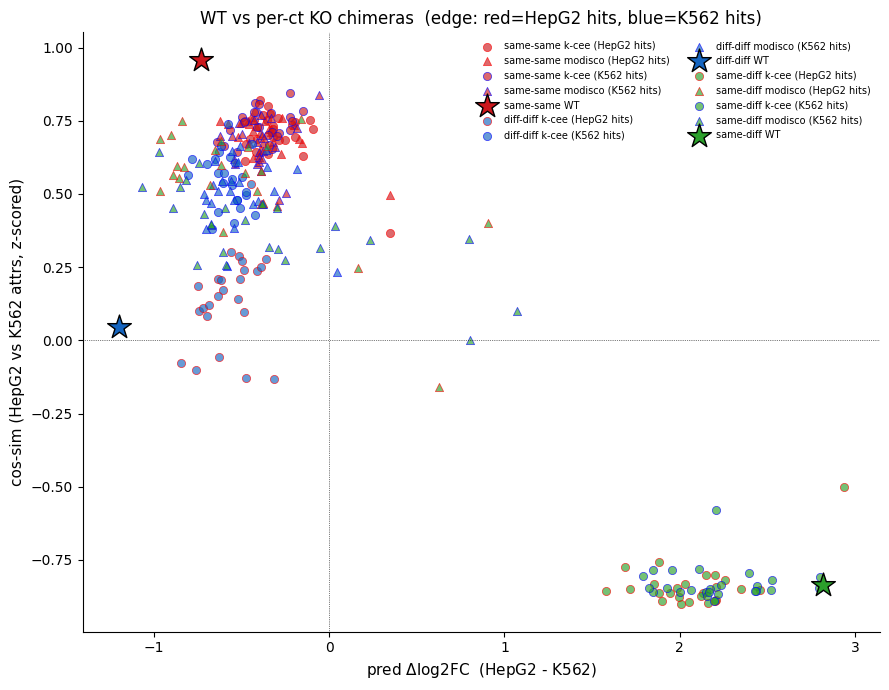

In [48]:
# Joint scatter: WTs and per-ct KO chimeras on
# (Δlog2FC HepG2 - K562, intra-seq cos-sim) plane.
# Each KO chimera is tagged with its annotation source ct (HepG2 or K562) — we
# never KO across cts. Marker shape = method, edgecolor = annotation ct.

cs_joint = em_kp.cosine_similarity(enhancer_only=True, mode='importance', zscore=True)
mdiff_joint = em_kp.predictions['HepG2'] - em_kp.predictions['K562']

ct_edge = {'HepG2': 'red', 'K562': 'blue'}

fig, ax = plt.subplots(figsize=(9, 7))
for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    col = group_color[name]
    for ct_anno in CTS:
        for method in ['k-cee', 'modisco']:
            m = np.array([t == ('KO', name, ct_anno, method) for t in tag2])
            if not m.any():
                continue
            ax.scatter(mdiff_joint[m], cs_joint[m], s=35, c=col,
                       marker=method_marker[method], alpha=0.65,
                       edgecolors=ct_edge[ct_anno], linewidths=0.6,
                       label=f'{name} {method} ({ct_anno} hits)')
    w = wt_pos2[name]
    ax.scatter([mdiff_joint[w]], [cs_joint[w]], s=320, c=col, marker='*',
               edgecolors='black', linewidths=1.0, zorder=5,
               label=f'{name} WT')

ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('pred $\\Delta$log2FC  (HepG2 - K562)', fontsize=11)
ax.set_ylabel('cos-sim (HepG2 vs K562 attrs, z-scored)', fontsize=11)
ax.set_title(f'WT vs per-ct KO chimeras  (edge: red=HepG2 hits, blue=K562 hits)')
ax.legend(fontsize=7, frameon=False, loc='best', ncol=2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

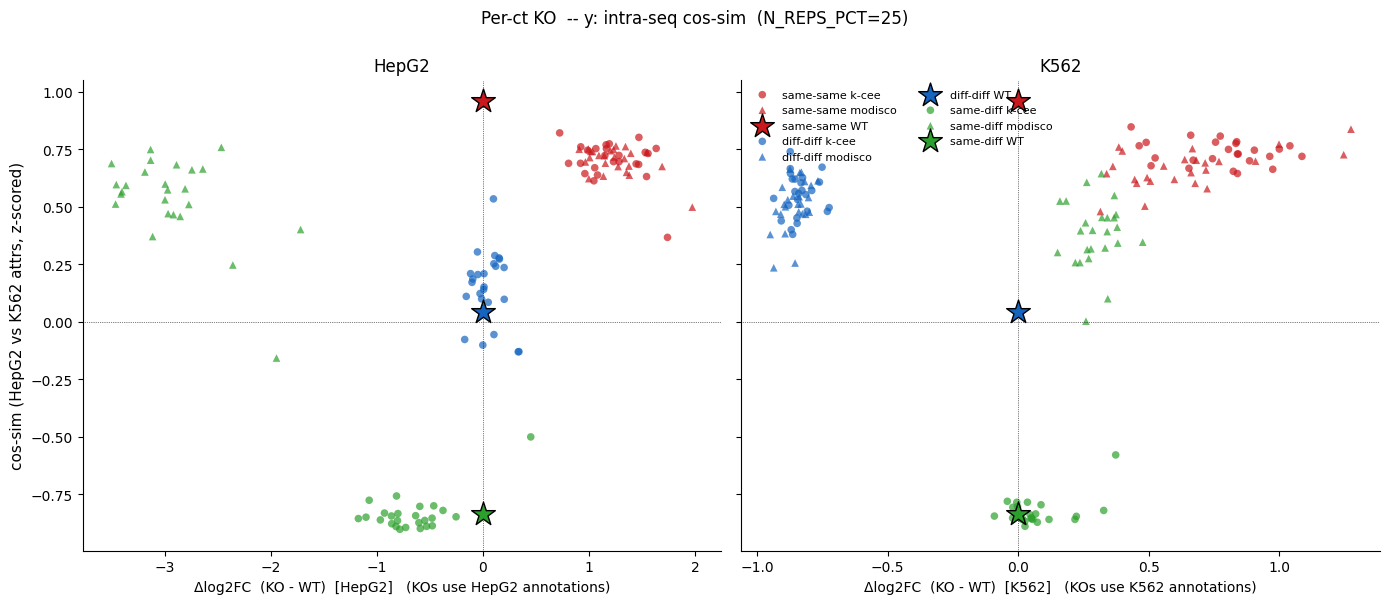

In [49]:
# Per-cell-line panels: x = Δlog2FC for that ct (KO - WT),
# y = intra-seq cos-sim (HepG2 vs K562) of the chimera.
# Strict per-ct: HepG2 panel only shows KOs built with HepG2 annotations,
# K562 panel only shows KOs built with K562 annotations.

wt_cs2 = {name: float(cs_joint[wt_pos2[name]])
          for name in ['same-same', 'diff-diff', 'same-diff']}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ci, ct in enumerate(CTS):
    ax = axes[ci]
    for name in ['same-same', 'diff-diff', 'same-diff']:
        col = group_color[name]
        for method in ['k-cee', 'modisco']:
            m = np.array([t == ('KO', name, ct, method) for t in tag2])
            if not m.any():
                continue
            dx = em_kp.predictions[ct][m] - wt_pred_ct2[name][ct]
            dy = cs_joint[m]
            ax.scatter(dx, dy, s=30, c=col,
                       marker=method_marker[method], alpha=0.7,
                       edgecolors='none', label=f'{name} {method}')
        ax.scatter([0], [wt_cs2[name]], s=320, c=col, marker='*',
                   edgecolors='black', linewidths=1.0, zorder=5,
                   label=f'{name} WT')
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.set_xlabel(f'Δlog2FC  (KO - WT)  [{ct}]   (KOs use {ct} annotations)', fontsize=10)
    if ci == 0:
        ax.set_ylabel('cos-sim (HepG2 vs K562 attrs, z-scored)', fontsize=11)
    ax.set_title(ct)
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

axes[-1].legend(fontsize=8, frameon=False, loc='best', ncol=2)
plt.suptitle(f'Per-ct KO  -- y: intra-seq cos-sim  (N_REPS_PCT={N_REPS_PCT})', y=1.00)
plt.tight_layout(); plt.show()

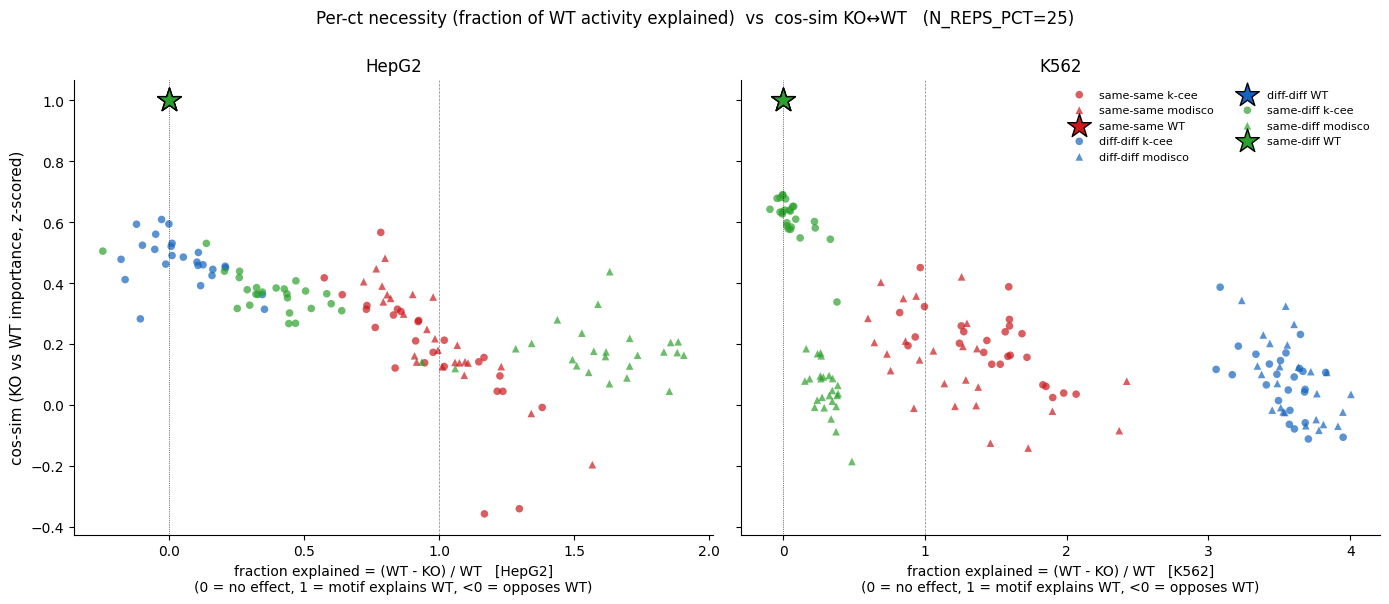

In [53]:
# Per-cell-line panels: necessity score normalized by WT magnitude.
#   necessity      = WT - KO                       (deviation due to motif KO)
#   frac_explained = necessity / WT
#     -> fraction of WT log2FC explained by the motifs, sign-corrected for direction
#     positive  motif drives WT direction (activator in active enhancer,
#               OR repressor in silenced enhancer — ratio cancels the sign)
#     ~1        motif explains all of WT activity (KO -> baseline 0)
#     >1        motif over-explains (KO flips WT sign)
#     negative  motif opposes WT direction
# y = cos-sim (KO vs WT importance, same ct, z-scored)
# Strict per-ct: HepG2 panel uses HepG2-annotated KOs only, etc.

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ci, ct in enumerate(CTS):
    ax = axes[ci]
    for name in ['same-same', 'diff-diff', 'same-diff']:
        col = group_color[name]
        cs_wt  = cos_to_wt2(ct, name)
        wt_val = wt_pred_ct2[name][ct]
        for method in ['k-cee', 'modisco']:
            m = np.array([t == ('KO', name, ct, method) for t in tag2])
            if not m.any():
                continue
            frac = (wt_val - em_kp.predictions[ct][m]) / wt_val
            ax.scatter(frac, cs_wt[m], s=30, c=col,
                       marker=method_marker[method], alpha=0.7,
                       edgecolors='none', label=f'{name} {method}')
        ax.scatter([0], [1.0], s=320, c=col, marker='*',
                   edgecolors='black', linewidths=1.0, zorder=5,
                   label=f'{name} WT')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.axvline(1, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel(f'fraction explained = (WT - KO) / WT   [{ct}]\n'
                  f'(0 = no effect, 1 = motif explains WT, <0 = opposes WT)',
                  fontsize=10)
    if ci == 0:
        ax.set_ylabel('cos-sim (KO vs WT importance, z-scored)', fontsize=11)
    ax.set_title(f'{ct}  (WT log2FC = {wt_pred_ct2["same-same"][ct]:+.2f}, etc.)' if False else ct)
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

axes[-1].legend(fontsize=8, frameon=False, loc='best', ncol=2)
plt.suptitle(f'Per-ct necessity (fraction of WT activity explained)  '
             f'vs  cos-sim KO↔WT   (N_REPS_PCT={N_REPS_PCT})', y=1.00)
plt.tight_layout(); plt.show()

In [ ]:
# Per-cell-line SUFFICIENCY: KI annotated motifs (at same positions/orientation)
# into dinuc-shuffled backbones of WT.
#   baseline = dinuc-shuffle(WT)  (no motif syntax)
#   KI       = baseline with WT motif sequence pasted back at annotated regions
#   sufficiency = (KI - baseline) / (WT - baseline)
#     -> fraction of WT-vs-baseline activity that motifs alone reconstitute
#     ~1   motifs alone fully recover WT activity
#     ~0   motifs add nothing on shuffled backbone
#     >1   motifs even more potent in shuffle context
#     <0   motifs push opposite of WT direction
# y = cos-sim (KI vs WT importance, same ct, z-scored)
# Strict per-ct: HepG2 panel uses HepG2-annotated KIs only, etc.

# --- knobs ---
N_REPS_KI = 25
# -------------

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle
ENH_LEN = eigen_steering.ENHANCER_LEN

# Build batch: WT once + per-(seq, ct, method) [baseline shuffles, KIs]
all_X3, tag3 = [], []
wt_pos3, base_pos3 = {}, {}   # base_pos3[(name, ct, method)] = (start, count)
for r, name in enumerate(['same-same', 'diff-diff', 'same-diff']):
    seq_i = sub_idx[r]
    wt = em.X[seq_i:seq_i+1].float()
    wt_pos3[name] = sum(t.shape[0] for t in all_X3)
    all_X3.append(wt); tag3.append(('WT', name))

    for ct_anno in CTS:
        for method in ['k-cee', 'modisco']:
            regs = merge_intervals(annotations_for(name, r, ct_anno, method))
            if not regs:
                print(f'  [skip] {name} {ct_anno} {method}: 0 regions')
                continue
            # shuffle backbones (paired baselines)
            shuf = dinuc_shuf(wt, n=N_REPS_KI,
                              random_state=int(seq_i)*257 + (hash(method) + hash(ct_anno)) % 1000)[0]
            base_start = sum(t.shape[0] for t in all_X3)
            all_X3.append(shuf)
            tag3 += [('BASE', name, ct_anno, method)] * N_REPS_KI

            # KI: copy WT motif sequence back into the shuffle at each region
            ki = shuf.clone()
            for s, e in regs:
                ki[:, :, s:e] = wt[:, :, s:e]
            all_X3.append(ki)
            tag3 += [('KI', name, ct_anno, method)] * N_REPS_KI

X3 = torch.cat(all_X3, dim=0)
em_ki = EigenMap(model_names=CT, device=DEVICE)
em_ki.X = X3
em_ki.constructs = [''] * X3.shape[0]
em_ki.enhancers  = [''] * X3.shape[0]
em_ki.compute_attributions(method='deeplift', n_shuffles=20, batch_size=128, verbose=True)

def cos_to_wt_ki(ct, name):
    imp_all = em_ki.importance[ct][:, :ENH_LEN]
    wt_imp  = imp_all[wt_pos3[name]]
    a = _zscore(imp_all); b = _zscore(wt_imp)
    a /= (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-12)
    b /= (np.linalg.norm(b) + 1e-12)
    return a @ b

wt_pred_ct3 = {name: {ct: float(em_ki.predictions[ct][wt_pos3[name]]) for ct in CTS}
               for name in ['same-same', 'diff-diff', 'same-diff']}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ci, ct in enumerate(CTS):
    ax = axes[ci]
    for name in ['same-same', 'diff-diff', 'same-diff']:
        col = group_color[name]
        cs_wt  = cos_to_wt_ki(ct, name)
        wt_val = wt_pred_ct3[name][ct]
        for method in ['k-cee', 'modisco']:
            ki_mask   = np.array([t == ('KI',   name, ct, method) for t in tag3])
            base_mask = np.array([t == ('BASE', name, ct, method) for t in tag3])
            if not ki_mask.any():
                continue
            ki_pred   = em_ki.predictions[ct][ki_mask]
            base_pred = em_ki.predictions[ct][base_mask]   # paired by replicate order
            denom = wt_val - base_pred
            denom = np.where(np.abs(denom) < 1e-6, np.sign(denom) * 1e-6 + 1e-9, denom)
            sufficiency = (ki_pred - base_pred) / denom
            ax.scatter(sufficiency, cs_wt[ki_mask], s=30, c=col,
                       marker=method_marker[method], alpha=0.7,
                       edgecolors='none', label=f'{name} {method}')
        ax.scatter([1], [1.0], s=320, c=col, marker='*',
                   edgecolors='black', linewidths=1.0, zorder=5,
                   label=f'{name} WT')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.axvline(1, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel(f'sufficiency = (KI - shuf) / (WT - shuf)   [{ct}]\n'
                  f'(0 = motifs add nothing, 1 = motifs reconstitute WT)',
                  fontsize=10)
    if ci == 0:
        ax.set_ylabel('cos-sim (KI vs WT importance, z-scored)', fontsize=11)
    ax.set_title(ct)
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

axes[-1].legend(fontsize=8, frameon=False, loc='best', ncol=2)
plt.suptitle(f'Per-ct sufficiency (motifs KI into shuffled backbone)  '
             f'(N_REPS_KI={N_REPS_KI})', y=1.00)
plt.tight_layout(); plt.show()

  [skip] diff-diff HepG2 modisco: 0 regions
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DeepLIFT/SHAP: K562...
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt


  0%|          | 0/11060 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.2166e-01, 2.2101e-01, 2.4427e-01, 1.1663e-01, 2.4604e-01, 1.7582e-01,
        3.5811e-01, 1.2278e-01, 1.5260e-01, 3.2461e-01, 1.0296e-01, 3.8428e-02,
        2.1168e-02, 9.6188e-02, 2.5834e-01, 2.0054e-01, 6.3298e-02, 1.8226e-01,
        5.7837e-01, 1.7515e-01, 8.3196e-02, 2.3922e-02, 2.4817e-02, 6.4139e-03,
        4.4936e-03, 1.5082e-02, 1.3965e-02, 6.1569e-02, 1.1666e-02, 4.1755e-02,
        3.6563e-02, 2.4682e-02, 2.9327e-02, 2.7052e-02, 3.6586e-02, 6.3377e-02,
        3.0881e-02, 8.4164e-02, 1.0744e-01, 9.0508e-02, 1.8918e-01, 9.7086e-03,
        3.0309e-02, 5.3274e-03, 6.0760e-03, 1.4766e-02, 2.5395e-01, 4.5670e-02,
        4.1970e-02, 7.7454e-02, 1.5082e-02, 5.2460e-03, 3.9357e-03, 2.3242e-01,
        2.7066e-02, 3.8616e-0

DeepLIFT/SHAP: HepG2...
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt


  0%|          | 0/11060 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.1772, 0.1203, 0.1000, 0.3104, 0.0445, 0.1995, 0.2505, 0.3285, 0.4728,
        0.0515, 0.2095, 0.1891, 0.0693, 0.3192, 0.1882, 0.3612, 0.0268, 0.1957,
        0.3707, 0.1420, 0.1047, 0.1111, 0.0239, 0.0450, 0.0628, 0.1348, 0.0462,
        0.0338, 0.0575, 0.0528, 0.0700, 0.0345, 0.1720, 0.0189, 0.1030, 0.0514,
        0.1015, 0.0402, 0.0688, 0.0217, 0.1242, 0.0752, 0.0111, 0.1218, 0.0806,
        0.1451, 0.0108, 0.0265, 0.0203, 0.2851, 0.0514, 0.1007, 0.2725, 0.0870,
        0.1743, 0.0664, 0.2237, 0.0238, 0.0974, 0.0253, 0.0851, 0.2652, 0.0285,
        0.0039, 0.0836, 0.0262, 0.0254, 0.0312, 0.0119, 0.0023, 0.0160, 0.0307,
        0.0283, 0.0375, 0.0488, 0.0648, 0.0023, 0.0114, 0.1410, 0.0525, 0.0224,
        0.2634, 0.0022, 0.040